
## Predict: Reason for Not Completing the Ride
(Cancelled by Customer / Cancelled by Driver / Incomplete)

**Imports**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Load Data**

In [5]:
df = pd.read_csv('/content/ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


**EDA**

In [6]:
df.shape

(150000, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [8]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [9]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [10]:
df['Booking Status'].value_counts()

,count
Booking Status,
Completed,93000
Cancelled by Driver,27000
No Driver Found,10500
Cancelled by Customer,10500
Incomplete,9000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

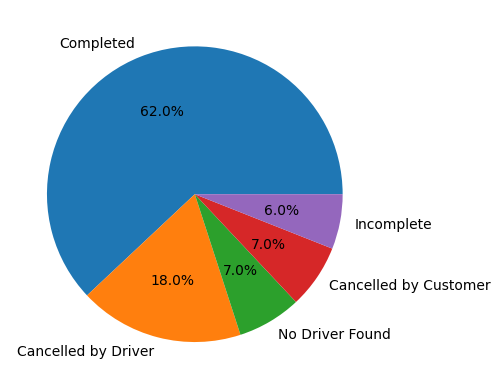

In [11]:
plt.pie(df['Booking Status'].value_counts(), labels=df['Booking Status'].value_counts().index, autopct='%1.1f%%')
plt

In [12]:
df['Reason for cancelling by Customer'].value_counts()

,count
Reason for cancelling by Customer,
Wrong Address,2362
Change of plans,2353
Driver is not moving towards pickup location,2335
Driver asked to cancel,2295
AC is not working,1155


In [13]:
df['Driver Cancellation Reason'].value_counts()

,count
Driver Cancellation Reason,
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686


In [14]:
df['Payment Method'].value_counts()

,count
Payment Method,
UPI,45909
Cash,25367
Uber Wallet,12276
Credit Card,10209
Debit Card,8239


In [15]:
df['Incomplete Rides Reason'].value_counts()

,count
Incomplete Rides Reason,
Customer Demand,3040
Vehicle Breakdown,3012
Other Issue,2948


In [16]:
df['Drop Location'].value_counts()

,count
Drop Location,
Ashram,936
Basai Dhankot,917
Lok Kalyan Marg,916
Narsinghpur,913
Cyber Hub,912
...,...
MG Road,799
Bhiwadi,792
Shivaji Park,786


In [17]:
df['Pickup Location'].value_counts()

,count
Pickup Location,
Khandsa,949
Barakhamba Road,946
Saket,931
Badarpur,921
Pragati Maidan,920
...,...
Mandi House,800
Noida Sector 18,799
Laxmi Nagar,797


In [18]:
df['Booking ID'].duplicated().sum()

np.int64(1233)

**Cleaning**

In [19]:
df_clean = df.drop_duplicates(subset='Booking ID').reset_index(drop=True)

df_clean = df_clean[df_clean['Booking Status'] != 'No Driver Found']

df_clean = df_clean.drop(
    ['Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides',
     'Avg CTAT', 'Customer Rating', 'Pickup Location', 'Drop Location', 'Driver Ratings','Booking ID','Customer ID','Booking Value'],
    axis=1
)

**Fix Data Types**

In [20]:
df_clean['Booking Status'] = df_clean['Booking Status'].astype('category')

df_clean['Date'] = df_clean['Date'].astype('datetime64[ns]')
df_clean['month'] = df_clean['Date'].dt.month
df_clean['day'] = df_clean['Date'].dt.day

df_clean['Vehicle Type'] = df_clean['Vehicle Type'].astype('category')
df_clean['Driver Cancellation Reason'] = df_clean['Driver Cancellation Reason'].astype('category')
df_clean['Incomplete Rides Reason'] = df_clean['Incomplete Rides Reason'].astype('category')
df_clean['Reason for cancelling by Customer'] = df_clean['Reason for cancelling by Customer'].astype('category')

df_clean['Ride Distance'] = df_clean['Ride Distance'].fillna(df_clean['Ride Distance'].mean())

df_clean['Payment Method'] = df_clean['Payment Method'].astype('category')
df_clean['Payment Method'] = df_clean['Payment Method'].fillna(df_clean['Payment Method'].mode()[0])

df_clean['Time'] = df_clean['Time'].astype('timedelta64[ns]')
df_clean['hour'] = df_clean['Time'].dt.components['hours']

**Encoding**

In [21]:
df_clean['Is_completed'] = (df_clean['Booking Status'] == 'Completed').astype(int)

la_Payment_Method = LabelEncoder()
la_Vehicle_Type = LabelEncoder()
df_clean['Payment Method'] = la_Payment_Method.fit_transform(df_clean['Payment Method'])
df_clean['Vehicle Type'] = la_Vehicle_Type.fit_transform(df_clean['Vehicle Type'])

**Split**

In [22]:
X = df_clean.drop(['Booking Status','Is_completed','Date','Time','Incomplete Rides Reason','Driver Cancellation Reason','Reason for cancelling by Customer'],axis=1)

y = df_clean['Is_completed']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30,stratify=y)

In [24]:
model_rf = RandomForestClassifier(class_weight='balanced',max_depth=5)
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5)

In [25]:
y_pred_rf = model_rf.predict(X_test)

In [26]:
# rf accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"test Accuracy for rf : {accuracy_rf:.2f}")

test Accuracy for rf : 0.89


**Canceled by who?**

In [27]:
df_clean2 = df_clean[df_clean['Booking Status'] != 'Completed'].copy().reset_index(drop=True)
df_clean2 = df_clean2.drop('Is_completed', axis=1)

la3 = LabelEncoder()
df_clean2['Booking Status'] = la3.fit_transform(df_clean2['Booking Status'])


dict(zip(la3.transform(la3.classes_), la3.classes_))

{np.int64(0): 'Cancelled by Customer',
 np.int64(1): 'Cancelled by Driver',
 np.int64(2): 'Incomplete'}

In [28]:
X2 = df_clean2.drop(
    ['Booking Status','Date','Time',
     'Incomplete Rides Reason', 'Driver Cancellation Reason', 'Reason for cancelling by Customer'],
    axis=1
)
y2 = df_clean2['Booking Status']

 **Train / Test Split**

In [29]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=30, stratify=y2
)

**Train**

In [30]:
model_nb = GaussianNB()
model_nb.fit(X2_train, y2_train)

GaussianNB()

In [31]:
y2_pred_nb = model_nb.predict(X2_test)
y2_pred_nb_train = model_nb.predict(X2_train)

print(f"Naive Bayes    -> Train: {accuracy_score(y2_train, y2_pred_nb_train):.2f} | Test: {accuracy_score(y2_test, y2_pred_nb):.2f}")

Naive Bayes    -> Train: 0.89 | Test: 0.89


**Predict the reason of cancelation**

In [32]:
# Incomplete DF
df_incomplete = df_clean2[df_clean2['Booking Status'] == 2].copy()
df_incomplete = df_incomplete[df_incomplete['Incomplete Rides Reason'] != 'Other Issue'].reset_index(drop=True)
df_incomplete = df_incomplete.drop(['Booking Status','Reason for cancelling by Customer','Driver Cancellation Reason'], axis=1)

# Cnaceled by customer DF
df_customer = df_clean2[df_clean2['Booking Status'] == 0].copy()
df_customer = df_customer[df_customer['Reason for cancelling by Customer'] != 'Wrong Address']
df_customer = df_customer[df_customer['Reason for cancelling by Customer'] != 'Change of plans']
df_customer = df_customer[df_customer['Reason for cancelling by Customer'] != 'Driver asked to cancel'].reset_index(drop=True)
df_customer = df_customer.drop(['Booking Status','Incomplete Rides Reason','Driver Cancellation Reason'], axis=1)

# Canceled by driver DF
df_driver = df_clean2[df_clean2['Booking Status'] == 1].copy()
df_driver = df_driver[(df_driver['Driver Cancellation Reason'] != 'More than permitted people in there') & (df_driver['Driver Cancellation Reason'] != 'The customer was coughing/sick')].reset_index(drop=True)
df_driver = df_driver.drop(['Booking Status','Incomplete Rides Reason','Reason for cancelling by Customer'], axis=1)

In [33]:
X_incomplete = df_incomplete.drop(['Incomplete Rides Reason','Date','Time'] ,axis=1)
y_incomplete = df_incomplete['Incomplete Rides Reason']

In [34]:
X_customer = df_customer.drop(['Reason for cancelling by Customer','Date','Time'], axis=1)
y_customer = df_customer['Reason for cancelling by Customer']

In [35]:
X_driver = df_driver.drop(['Driver Cancellation Reason','Date','Time'], axis=1)
y_driver = df_driver['Driver Cancellation Reason']

**Encoding**

In [36]:
la_incomplete = LabelEncoder()
y_incomplete = la_incomplete.fit_transform(y_incomplete)

la_customer = LabelEncoder()
y_customer = la_customer.fit_transform(y_customer)

la_driver = LabelEncoder()
y_driver = la_driver.fit_transform(y_driver)

**Split**

In [37]:
X_incomplete_train, X_incomplete_test, y_incomplete_train, y_incomplete_test = train_test_split(
    X_incomplete, y_incomplete, test_size=0.2, random_state=30)

In [38]:
X_customer_train, X_customer_test, y_customer_train, y_customer_test = train_test_split(
    X_customer, y_customer, test_size=0.2, random_state=30
)

In [39]:
X_driver_train, X_driver_test, y_driver_train, y_driver_test = train_test_split(
    X_driver, y_driver, test_size=0.2, random_state=30
)

# **Incomplete reason prediction**

In [40]:
# dt
model_dt_incomplete = DecisionTreeClassifier(class_weight='balanced', max_depth=5)
model_dt_incomplete.fit(X_incomplete_train, y_incomplete_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

In [41]:
# naive
model_nb_incomplete = GaussianNB()
model_nb_incomplete.fit(X_incomplete_train, y_incomplete_train)

GaussianNB()

In [42]:
# ada
model_ada_incomplete = AdaBoostClassifier()
model_ada_incomplete.fit(X_incomplete_train, y_incomplete_train)

AdaBoostClassifier()

In [43]:
y_pred_dt_incomplete = model_dt_incomplete.predict(X_incomplete_test)
y_pred_dt_incomplete_train = model_dt_incomplete.predict(X_incomplete_train)

y_pred_nb_incomplete = model_nb_incomplete.predict(X_incomplete_test)
y_pred_nb_incomplete_train = model_nb_incomplete.predict(X_incomplete_train)

y_pred_ada_incomplete = model_ada_incomplete.predict(X_incomplete_test)
y_pred_ada_incomplete_train = model_ada_incomplete.predict(X_incomplete_train)

In [44]:
Accuracy_dt_incomplete = accuracy_score(y_incomplete_test, y_pred_dt_incomplete)
Accuracy_nb_incomplete = accuracy_score(y_incomplete_test, y_pred_nb_incomplete)
Accuracy_ada_incomplete = accuracy_score(y_incomplete_test, y_pred_ada_incomplete)

print(f"Decision Tree  -> Train: {accuracy_score( y_incomplete_train,y_pred_dt_incomplete_train):.2f} | Test: {accuracy_score( y_incomplete_test, y_pred_dt_incomplete):.2f}")

print(f"Naive Bayes    -> Train: {accuracy_score( y_incomplete_train,y_pred_nb_incomplete_train):.2f} | Test: {accuracy_score( y_incomplete_test, y_pred_nb_incomplete):.2f}")

print(f"AdaBoost       -> Train: {accuracy_score( y_incomplete_train,y_pred_ada_incomplete_train):.2f} | Test: {accuracy_score( y_incomplete_test, y_pred_ada_incomplete):.2f}")

Decision Tree  -> Train: 0.54 | Test: 0.51
Naive Bayes    -> Train: 0.51 | Test: 0.50
AdaBoost       -> Train: 0.53 | Test: 0.49


# **Driver cancelation reason prediction**

In [45]:
# dt
model_dt_driver = DecisionTreeClassifier(class_weight='balanced', max_depth=5)
model_dt_driver.fit(X_driver_train, y_driver_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

In [46]:
# nb
model_nb_driver = GaussianNB()
model_nb_driver.fit(X_driver_train, y_driver_train)

GaussianNB()

In [47]:
# ada
model_ada_driver = AdaBoostClassifier()
model_ada_driver.fit(X_driver_train, y_driver_train)

AdaBoostClassifier()

In [48]:
y_pred_dt_driver = model_dt_driver.predict(X_driver_test)
y_pred_dt_driver_train = model_dt_driver.predict(X_driver_train)

y_pred_nb_driver = model_nb_driver.predict(X_driver_test)
y_pred_nb_driver_train = model_nb_driver.predict(X_driver_train)

y_pred_ada_driver = model_ada_driver.predict(X_driver_test)
y_pred_ada_driver_train = model_ada_driver.predict(X_driver_train)

In [49]:
Accuracy_dt_driver = accuracy_score(y_driver_test, y_pred_dt_driver)
Accuracy_nb_driver = accuracy_score(y_driver_test, y_pred_nb_driver)
Accuracy_ada_driver = accuracy_score(y_driver_test, y_pred_ada_driver)


print(f"Decision Tree  -> Train: {accuracy_score( y_driver_train,y_pred_dt_driver_train):.2f} | Test: {accuracy_score( y_driver_test, y_pred_dt_driver):.2f}")

print(f"Naive Bayes    -> Train: {accuracy_score( y_driver_train,y_pred_nb_driver_train):.2f} | Test: {accuracy_score( y_driver_test, y_pred_nb_driver):.2f}")

print(f"AdaBoost       -> Train: {accuracy_score( y_driver_train,y_pred_ada_driver_train):.2f} | Test: {accuracy_score( y_driver_test, y_pred_ada_driver):.2f}")

Decision Tree  -> Train: 0.54 | Test: 0.48
Naive Bayes    -> Train: 0.51 | Test: 0.50
AdaBoost       -> Train: 0.53 | Test: 0.49


# **Cancelation by costumer reason**

In [50]:
# dt
model_dt_customer = DecisionTreeClassifier(class_weight='balanced', max_depth=5)
model_dt_customer.fit(X_customer_train, y_customer_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

In [51]:
# nb
model_nb_customer = GaussianNB()
model_nb_customer.fit(X_customer_train, y_customer_train)

GaussianNB()

In [52]:
# ada
model_ada_customer = AdaBoostClassifier()
model_ada_customer.fit(X_customer_train, y_customer_train)

AdaBoostClassifier()

In [53]:
y_pred_dt_customer = model_dt_customer.predict(X_customer_test)
y_pred_dt_customer_train = model_dt_customer.predict(X_customer_train)

y_pred_nb_customer = model_nb_customer.predict(X_customer_test)
y_pred_nb_customer_train = model_nb_customer.predict(X_customer_train)

y_pred_ada_customer = model_ada_customer.predict(X_customer_test)
y_pred_ada_customer_train = model_ada_customer.predict(X_customer_train)

In [54]:
Accuracy_dt_customer = accuracy_score(y_customer_test, y_pred_dt_customer)
Accuracy_nb_customer = accuracy_score(y_customer_test, y_pred_nb_customer)
Accuracy_ada_customer = accuracy_score(y_customer_test, y_pred_ada_customer)

print(f"Decision Tree  -> Train: {accuracy_score( y_customer_train,y_pred_dt_customer_train):.2f} | Test: {accuracy_score( y_customer_test, y_pred_dt_customer):.2f}")

print(f"Naive Bayes    -> Train: {accuracy_score( y_customer_train,y_pred_nb_customer_train):.2f} | Test: {accuracy_score( y_customer_test, y_pred_nb_customer):.2f}")

print(f"AdaBoost       -> Train: {accuracy_score( y_customer_train,y_pred_ada_customer_train):.2f} | Test: {accuracy_score( y_customer_test, y_pred_ada_customer):.2f}")

Decision Tree  -> Train: 0.69 | Test: 0.68
Naive Bayes    -> Train: 0.67 | Test: 0.63
AdaBoost       -> Train: 0.68 | Test: 0.68


In [ ]:
!pip install -q gradio


In [ ]:
import gradio as gr
import pandas as pd

def predict_ride(vehicle_type, payment_method, avg_vtat, ride_distance, month, day, hour):
    vt_code = la_Vehicle_Type.transform([vehicle_type])[0]
    pm_code = la_Payment_Method.transform([payment_method])[0]
    row = pd.DataFrame([{
        'Vehicle Type': vt_code,
        'Avg VTAT': avg_vtat,
        'Ride Distance': ride_distance,
        'Payment Method': pm_code,
        'month': month,
        'day': day,
        'hour': hour
    }])
    is_completed = model_rf.predict(row)[0]
    if is_completed == 1:
        return "Completed"
    status_code = model_nb.predict(row)[0]
    status_text = la3.inverse_transform([status_code])[0]
    if status_text == 'Incomplete':
        best_acc = max(Accuracy_dt_incomplete, Accuracy_nb_incomplete, Accuracy_ada_incomplete)
        if best_acc == Accuracy_dt_incomplete:
            reason_code = model_dt_incomplete.predict(row)[0]
        elif best_acc == Accuracy_nb_incomplete:
            reason_code = model_nb_incomplete.predict(row)[0]
        else:
            reason_code = model_ada_incomplete.predict(row)[0]
        reason_text = la_incomplete.inverse_transform([reason_code])[0]
    elif status_text == 'Cancelled by Customer':
        best_acc = max(Accuracy_dt_customer, Accuracy_nb_customer, Accuracy_ada_customer)
        if best_acc == Accuracy_dt_customer:
            reason_code = model_dt_customer.predict(row)[0]
        elif best_acc == Accuracy_nb_customer:
            reason_code = model_nb_customer.predict(row)[0]
        else:
            reason_code = model_ada_customer.predict(row)[0]
        reason_text = la_customer.inverse_transform([reason_code])[0]
    elif status_text == 'Cancelled by Driver':
        best_acc = max(Accuracy_dt_driver, Accuracy_nb_driver, Accuracy_ada_driver)
        if best_acc == Accuracy_dt_driver:
            reason_code = model_dt_driver.predict(row)[0]
        elif best_acc == Accuracy_nb_driver:
            reason_code = model_nb_driver.predict(row)[0]
        else:
            reason_code = model_ada_driver.predict(row)[0]
        reason_text = la_driver.inverse_transform([reason_code])[0]
    else:
        reason_text = ""
    return f"{status_text} - {reason_text}"

vehicle_choices = list(la_Vehicle_Type.classes_)
payment_choices = list(la_Payment_Method.classes_)

with gr.Blocks() as demo:
    vehicle_type_in = gr.Dropdown(choices=vehicle_choices, label="Vehicle Type")
    payment_method_in = gr.Dropdown(choices=payment_choices, label="Payment Method")
    avg_vtat_in = gr.Number(label="Avg VTAT", minimum=2, maximum=20)
    ride_distance_in = gr.Number(label="Ride Distance", minimum=1, maximum=50)
    month_in = gr.Number(label="Month", minimum=1, maximum=12)
    day_in = gr.Number(label="Day", minimum=1, maximum=30)
    hour_in = gr.Number(label="Hour", minimum=0, maximum=23)
    output = gr.Textbox(label="Prediction")
    btn = gr.Button("Predict")
    btn.click(predict_ride, inputs=[vehicle_type_in, payment_method_in, avg_vtat_in, ride_distance_in, month_in, day_in, hour_in], outputs=output)

demo.launch(share=True, debug=True)
